In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Import the Dataset
df= pd.read_csv("../dataset/English-OSINT.csv")
display(df)

,email_text,email_type
0,Hello I am your hot lil horny toy.\n I am t...,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...",Safe Email
4,The academic discipline of Software Engineerin...,Safe Email
...,...,...
1479,"Two issues:----\nSorry, but the following pack...",Safe Email
1480,"howdy all,I have in my possession the followin...",Safe Email
1481,Sorry i know this is off topic:Ive recently go...,Safe Email
1482,"At 3:39 PM -0500 8/21/02, Rice, MA Mark (6750 ...",Safe Email


In [4]:
# Check NAN values
df.isnull().sum()

email_text    0
email_type    0
dtype: int64

In [57]:
#Drop tha Na values
# df = df.dropna()
# print(df.isna().sum())

Unnamed: 0    0
Email Text    0
Email Type    0
dtype: int64


In [5]:
#dataset shape
df.shape

(1484, 2)

In [6]:
# # Count the occurrences of each E-mail type. 
email_type_counts = df['email_type'].value_counts()
print(email_type_counts)

email_type
Safe Email        1232
Phishing Email     252
Name: count, dtype: int64


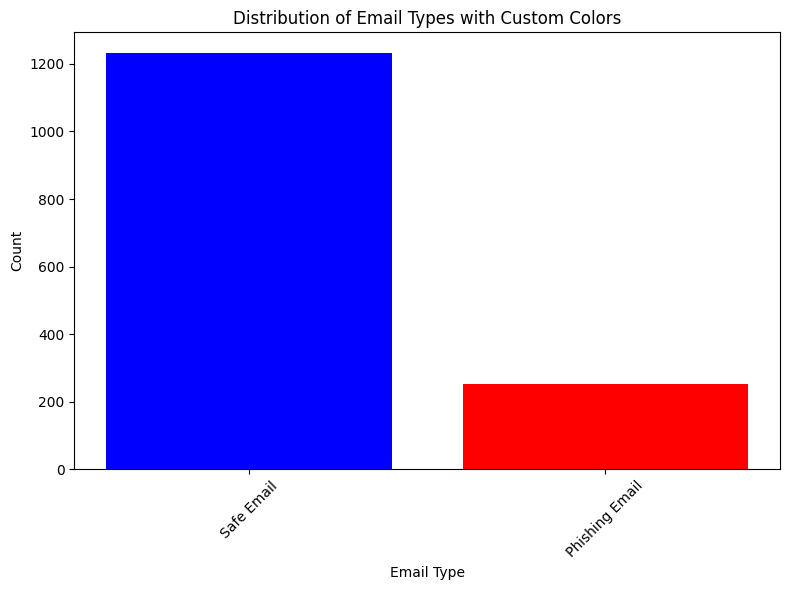

In [7]:
# Create the bar chart
# Create a list of unique email types
unique_email_types = email_type_counts.index.tolist()

# Define a custom color map 
color_map = {
    'Phishing Email': 'red',
    'Safe Email': 'blue',}

# Map the colors to each email type
colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# Create the bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(unique_email_types, email_type_counts, color=colors)
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.title('Distribution of Email Types with Custom Colors')
plt.xticks(rotation=45)

# Show the chart
plt.tight_layout()
plt.show()

In [8]:
# # We will use undersapling technique 
Safe_Email = df[df["email_type"]== "Safe Email"]
Phishing_Email = df[df["email_type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [9]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

((252, 2), (252, 2))

In [10]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()
display(Data)

,email_text,email_type
0,"> Special Bonus with your order, you will rece...",Safe Email
1,"On Wednesday, August 28, 2002, at 04:38 PM, D...",Safe Email
2,URL: http://boingboing.net/#85485894\nDate: No...,Safe Email
3,">>>>> ""S"" == Stephen D Williams writes: S>...",Safe Email
4,"Thanks Tony, but I think doing it using compon...",Safe Email
...,...,...
499,*** Attention: US Citizens *** Earn extra mone...,Phishing Email
500,"Hey there,If you're like me, you've tried EVER...",Phishing Email
501,SEE a Teen Farm Girl Do it with her horse see ...,Phishing Email
502,AnÂ Â I n f o r m a t i o n Â \n Â \nÂ \nÂ ...,Phishing Email


In [11]:
# # split the data into a metrix of features X and Dependent Variable y
X = Data["email_text"].values
y = Data["email_type"].values

In [12]:
# lets splitting Our Data 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 1)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf = TfidfVectorizer()

# Fit and transform X_train (and transform X_test)
X_train_tfidf = tfidf.fit_transform(X_train)  # Converts text to numeric matrix
X_test_tfidf = tfidf.transform(X_test)       # Use the same transformation on test data


In [14]:
# instantiate the DecisionTreeClassifier model with criterion gini index
from sklearn.tree import DecisionTreeClassifier
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# fit the model
clf_gini.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [15]:
y_pred_gini = clf_gini.predict(X_test_tfidf)

In [69]:
# print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

In [16]:
y_pred_train_gini = clf_gini.predict(X_train_tfidf)

In [71]:
# print('\nTraining-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

In [17]:
# record accuracy in file
from sklearn.metrics import accuracy_score
with open("english_only_DT_result.txt", "a") as file:
    file.write(f"\n(criterion=gini)\n Training set score: {accuracy_score(y_train, y_pred_train_gini):.4f}\n Test set score:{accuracy_score(y_test, y_pred_gini):.4f}")

In [18]:
from sklearn.tree import DecisionTreeClassifier
clf_entro = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
clf_entro.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [19]:
y_pred_entro = clf_entro.predict(X_test_tfidf)

In [75]:
# from sklearn.metrics import accuracy_score

# print('\nModel accuracy score with criterion entropy index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_entro)))

In [20]:
y_pred_train_entro = clf_entro.predict(X_train_tfidf)

# y_pred_train_entro

In [77]:
# print('\nTraining-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_entro)))

In [48]:
# record accuracy in file
with open("english_only_DT_result.txt", "a") as file:
    file.write(f"\n(criterion=entropy)\nTraining set score: {accuracy_score(y_train, y_pred_train_entro):.4f}\n Test set score:{accuracy_score(y_test, y_pred_entro):.4f}")